In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('products_asos.csv')

df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna(subset=['price'])



In [2]:
df['description'] = df['description'].astype(str)

def get_brand(text):
    
    if 'by ' in text:
        try:
            return text.split('by ')[1].split()[0]

        except:
            return 'Unknown'
    else:
        return 'Unknown'

In [3]:
df['brand'] = df['description'].apply(get_brand)

df.head()

,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket


In [4]:
brand_map = {

    'New' : 'New Look',
    'Vero': 'Vero Moda',
    'Native': 'Native Youth',
    'Carhartt': 'Carhartt WIP',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

df['brand'] = df['brand'].map(brand_map).fillna(df['brand'])

brand_counts = df['brand'].value_counts()

valid_brands = brand_counts[brand_counts > 5].index

df_cleaned = df[df['brand'].isin(valid_brands)].copy()

print(df_cleaned['brand'].value_counts().head(5))

brand
ASOS              4844
Topshop           1017
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


In [5]:
print(plt)
print(type(plt))

<module 'matplotlib.pyplot' from '/Users/rahaman/Library/Python/3.9/lib/python/site-packages/matplotlib/pyplot.py'>
<class 'module'>


In [7]:
def get_num_outof_stock(size_str):

    if not isinstance(size_str, str):
        return 0, 0.0

    size = size_str.split(',')
    total = len(size)

    out_of_stock_count = size_str.count('Out of stock')

    rate = out_of_stock_count / total if total > 0 else 0.0

    return out_of_stock_count, rate
    

matrices = df_cleaned['size'].apply(lambda x: get_num_outof_stock(x))

df_cleaned['Stockout_count'] = [x[0] for x in matrices]
df_cleaned['Stockout_rate'] = [x[1] for x in matrices]

df_cleaned['Lost_Revenue'] = df_cleaned['price'] * df_cleaned['Stockout_count']

cols = ['brand', 'name', 'price', 'Stockout_count', 'Lost_Revenue']

print(df_cleaned.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])




         brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


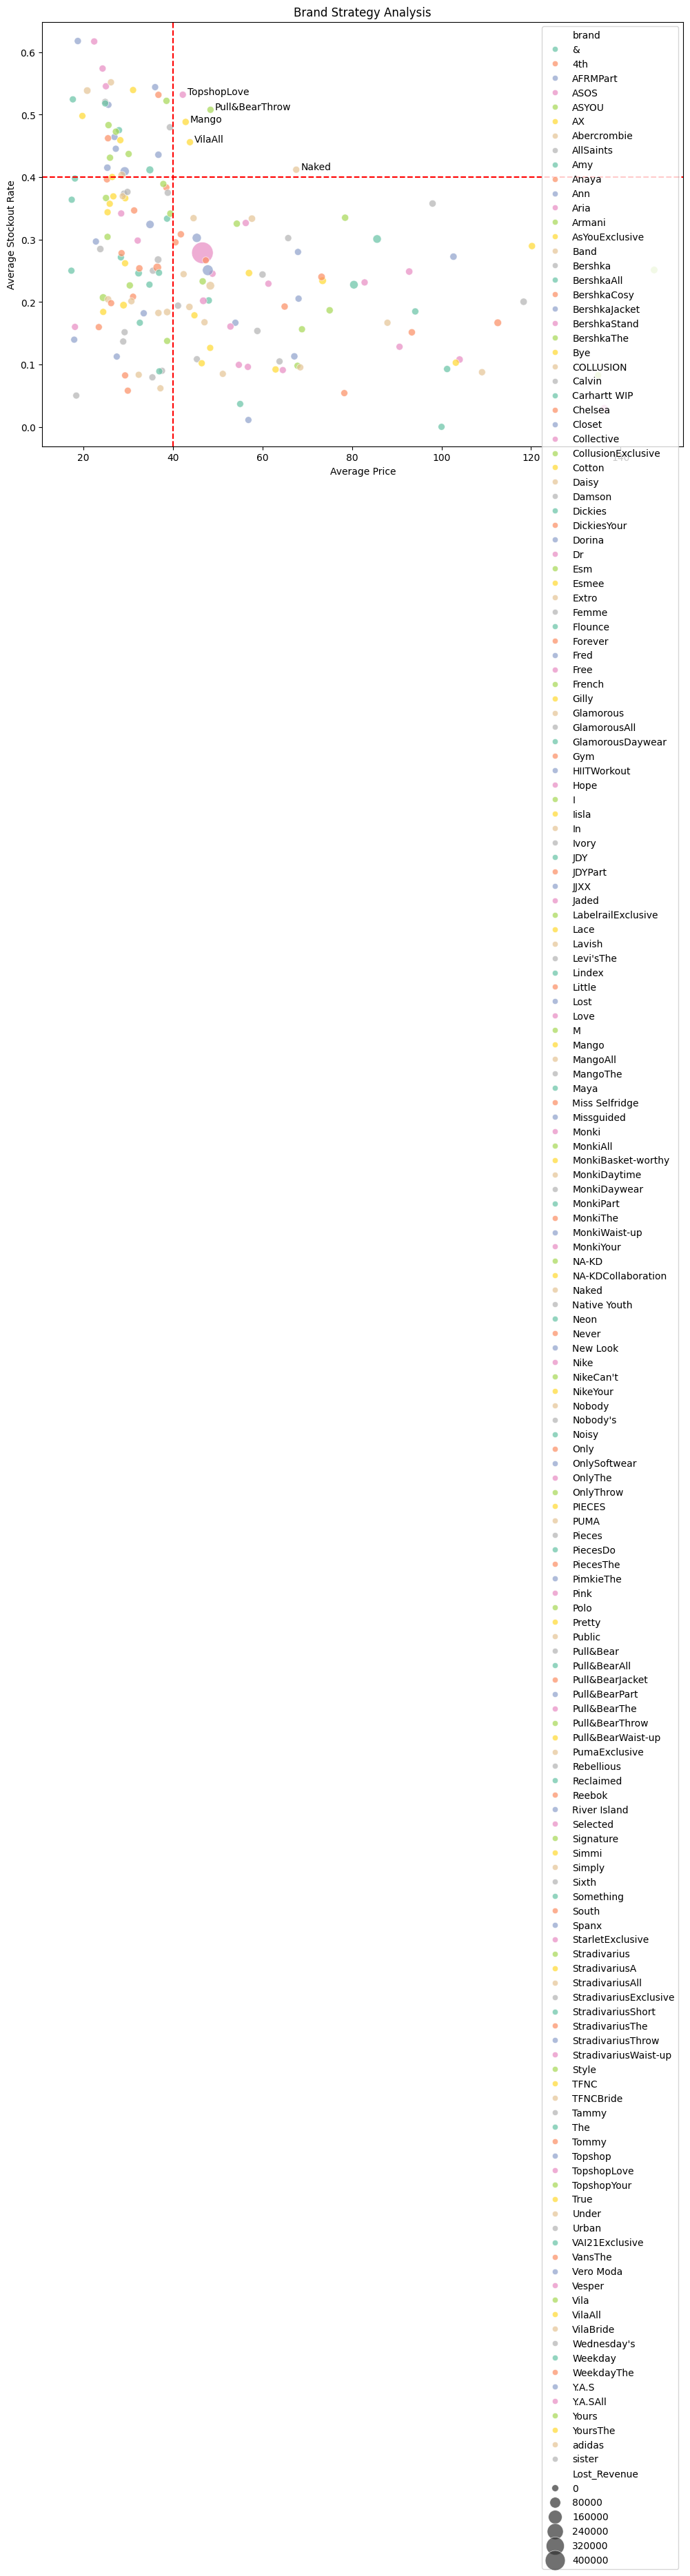

In [15]:
brand_strategy = df_cleaned.groupby('brand').agg({

    'Lost_Revenue': 'sum',
    'Stockout_rate': 'mean',
    'price': 'mean',
    'name': 'count'
}).reset_index() 

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_rate',
    size='Lost_Revenue',
    hue='brand',
    sizes=(50, 500),
    alpha=0.7,
    palette='Set2'
)

winners = brand_strategy[
    (brand_strategy['price'] > 40) & 
    (brand_strategy['Stockout_rate'] > 0.4)
]
for i in range(winners.shape[0]):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_rate'],
        winners.iloc[i]['brand'],
    )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Average Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')

plt.show()
